<a href="https://colab.research.google.com/github/Fatema5007/Deep-Learning-Foundations/blob/main/Task1_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Reliable, permanent open-source mirror for the Pima Indians Diabetes Dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

# Reading the dataset and applying official column names
df = pd.read_csv(url, names=column_names)

print("Kaggle Dataset successfully loaded via reliable mirror!")
print(f"Total rows and columns: {df.shape}")
print("\nDataset Features:")
print(df.columns.tolist())
df.head()

Kaggle Dataset successfully loaded via reliable mirror!
Total rows and columns: (768, 9)

Dataset Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# Split data into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PyTorch Custom Dataset Class
class DiabetesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders (Batch Size = 32)
train_dataset = DiabetesDataset(X_train, y_train)
test_dataset = DiabetesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Data Pipeline Ready!")
print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")

Data Pipeline Ready!
Training samples: 614, Testing samples: 154


In [ ]:
class DiabetesANN(nn.Module):
    def __init__(self, input_dim, use_batch_norm=False, dropout_rate=0.3):
        super(DiabetesANN, self).__init__()

        # Hidden Layer 1 (64 neurons)
        self.fc1 = nn.Linear(input_dim, 64)
        self.bn1 = nn.BatchNorm1d(64) if use_batch_norm else nn.Identity()
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        # Hidden Layer 2 (32 neurons)
        self.fc2 = nn.Linear(64, 32)
        self.bn2 = nn.BatchNorm1d(32) if use_batch_norm else nn.Identity()
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        # Output Layer
        self.out = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.dropout1(self.relu1(self.bn1(self.fc1(x))))
        x = self.dropout2(self.relu2(self.bn2(self.fc2(x))))
        return self.sigmoid(self.out(x))

print("ANN Model Architecture Defined Successfully!")

ANN Model Architecture Defined Successfully!


In [ ]:
def train_and_evaluate(use_bn, epochs=60):
    torch.manual_seed(42) # Ensuring reproducibility

    model = DiabetesANN(input_dim=8, use_batch_norm=use_bn, dropout_rate=0.3)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    loss_history = []

    # Training Loop
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(train_loader))

    # Evaluation Loop
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.numpy())
            all_targets.extend(batch_y.numpy())

    # Metrics Calculation
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds)
    rec = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)

    return loss_history, {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

print("Training Pipeline Engine Ready!")

Training Pipeline Engine Ready!


1. Training Model WITHOUT Batch Normalization...
2. Training Model WITH Batch Normalization...

Performance Metric | Without Batch Norm | With Batch Norm
Accuracy           | 0.7143             | 0.7013         
Precision          | 0.5846             | 0.5789         
Recall             | 0.6909             | 0.6000         
F1-Score           | 0.6333             | 0.5893         


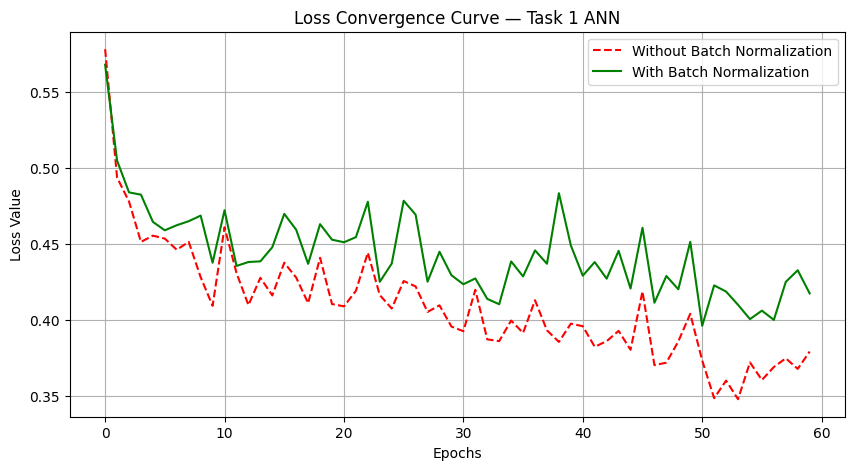

In [ ]:
# Run experiments for both setups
print("1. Training Model WITHOUT Batch Normalization...")
loss_no_bn, metrics_no_bn = train_and_evaluate(use_bn=False, epochs=60)

print("2. Training Model WITH Batch Normalization...")
loss_with_bn, metrics_with_bn = train_and_evaluate(use_bn=True, epochs=60)

# Print Final Comparison Table
print("\n" + "="*55)
print(f"{'Performance Metric':<18} | {'Without Batch Norm':<18} | {'With Batch Norm':<15}")
print("="*55)
for key in metrics_no_bn.keys():
    print(f"{key:<18} | {metrics_no_bn[key]:<18.4f} | {metrics_with_bn[key]:<15.4f}")
print("="*55)

# Plot Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(loss_no_bn, label='Without Batch Normalization', color='red', linestyle='--')
plt.plot(loss_with_bn, label='With Batch Normalization', color='green')
plt.title('Loss Convergence Curve — Task 1 ANN')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)
plt.show()